# 🔊 SoundWatch v5 — Transfer Learning avec YAMNet

Approche pro : on utilise **YAMNet** (modèle Google pré-entraîné sur 2 millions de sons) pour extraire des embeddings riches, puis on entraîne un petit classifieur dessus.

**Pipeline :**
```
audio.wav → YAMNet (pré-entraîné Google) → embedding (1024d) → petit MLP → 5 classes
```

**Avantages :**
- Entraînement ultra rapide (30 secondes)
- Performance attendue : 85-95% (vs 52% avec CNN custom)
- Argument démo : *"State-of-the-art audio embedding model"*

**Run All** une fois les classes choisies dans la cellule de config.

## 1. Installation (à faire UNE seule fois)

In [1]:
# Décommente la première fois
#!pip install tensorflow-hub
#!pip install pip install seaborn tqdm

## 2. Imports

In [2]:
#!pip install seaborn tqdm

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import json
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import tensorflow as tf
import tensorflow_hub as hub

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print(f'TensorFlow : {tf.__version__}')
print(f'TensorFlow Hub : {hub.__version__}')

TensorFlow : 2.16.2
TensorFlow Hub : 0.16.1


## 3. Configuration — choisis tes classes ici

In [4]:
# ============================================================
# CHANGE TES CLASSES ICI selon ton pitch
# ============================================================

# Option A — Alertes sonores pour sourds (le pitch original)
SELECTED_CATEGORIES = [
    'siren',
    'clock_alarm',
    'crying_baby',
    'door_wood_knock',
    'clapping',
]

# Option B — Sons distincts (plus facile, démo générique)
# SELECTED_CATEGORIES = [
#     'crying_baby',
#     'clapping',
#     'dog',
#     'cat',
#     'glass_breaking',
# ]

# Chemins
ESC50_DIR = Path('./esc50')
AUDIO_DIR = ESC50_DIR / 'audio'
MODEL_DIR = Path('./models')
MODEL_DIR.mkdir(exist_ok=True)

print(f'Classes selectionnees : {SELECTED_CATEGORIES}')
print(f'Nombre de classes : {len(SELECTED_CATEGORIES)}')

Classes selectionnees : ['siren', 'clock_alarm', 'crying_baby', 'door_wood_knock', 'clapping']
Nombre de classes : 5


## 4. Charger YAMNet (~1 min de téléchargement la première fois)

In [5]:
print('🔧 Chargement de YAMNet depuis TensorFlow Hub...')
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print('✅ YAMNet chargé.')

# Test rapide pour voir la structure
test_audio = np.zeros(16000, dtype=np.float32)  # 1 sec de silence
scores, embeddings, spectrogram = yamnet_model(test_audio)
print(f'\nFormat de sortie YAMNet :')
print(f'  scores       : {scores.shape}   (probas sur 521 classes)')
print(f'  embeddings   : {embeddings.shape}   (1024 dimensions par fenêtre)')
print(f'  spectrogram  : {spectrogram.shape}')

🔧 Chargement de YAMNet depuis TensorFlow Hub...
✅ YAMNet chargé.

Format de sortie YAMNet :
  scores       : (2, 521)   (probas sur 521 classes)
  embeddings   : (2, 1024)   (1024 dimensions par fenêtre)
  spectrogram  : (144, 64)


## 5. Charger les métadonnées ESC-50 et filtrer

In [6]:
ESC50_RAW_BASE = 'https://raw.githubusercontent.com/karoldvl/ESC-50/master'
meta = pd.read_csv(f'{ESC50_RAW_BASE}/meta/esc50.csv')

# Filtrer aux classes sélectionnées
df = meta[meta['category'].isin(SELECTED_CATEGORIES)].copy().reset_index(drop=True)

# Mapping
category_to_idx = {cat: i for i, cat in enumerate(SELECTED_CATEGORIES)}
idx_to_category = {i: cat for cat, i in category_to_idx.items()}
df['label'] = df['category'].map(category_to_idx)

print(f'Total fichiers : {len(df)}')
print(f'\nRépartition :')
for idx, cat in idx_to_category.items():
    n = (df['label'] == idx).sum()
    print(f'  {idx}  {cat:20s} : {n}')

Total fichiers : 200

Répartition :
  0  siren                : 40
  1  clock_alarm          : 40
  2  crying_baby          : 40
  3  door_wood_knock      : 40
  4  clapping             : 40


## 6. Extraire les embeddings YAMNet pour tous les fichiers (~2-3 min)

In [7]:
def extract_yamnet_embedding(filepath):
    """Charge un audio, le passe dans YAMNet, retourne l'embedding moyen."""
    # YAMNet attend 16000 Hz mono float32
    y, sr = librosa.load(filepath, sr=16000, mono=True)
    y = y.astype(np.float32)
    
    # Passer dans YAMNet
    scores, embeddings, spectrogram = yamnet_model(y)
    
    # Embeddings : (n_frames, 1024). On fait la moyenne pour avoir 1 vecteur par fichier.
    embedding_avg = tf.reduce_mean(embeddings, axis=0).numpy()
    return embedding_avg


print('Extraction des embeddings YAMNet...')
X_emb = []
y_list = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    filepath = AUDIO_DIR / row['filename']
    emb = extract_yamnet_embedding(filepath)
    X_emb.append(emb)
    y_list.append(row['label'])

X_emb = np.array(X_emb, dtype=np.float32)
y_emb = np.array(y_list)

print(f'\nShape X_emb : {X_emb.shape}  (N fichiers, 1024 dim)')
print(f'Shape y_emb : {y_emb.shape}')

Extraction des embeddings YAMNet...


  0%|                                                                                          | 0/200 [00:00<?, ?it/s]/Users/jean-christophebertincourt/.pyenv/versions/3.10.6/envs/sensi-front/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:06<00:00, 29.47it/s]


Shape X_emb : (200, 1024)  (N fichiers, 1024 dim)
Shape y_emb : (200,)


## 7. Split train / val

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_emb, y_emb,
    test_size=0.2,
    stratify=y_emb,
    random_state=42,
)

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')

X_train : (160, 1024)
X_val   : (40, 1024)


## 8. Petit MLP qui apprend sur les embeddings

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_classes = len(SELECTED_CATEGORIES)

classifier = Sequential([
    Input(shape=(1024,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(n_classes, activation='softmax'),
])

classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,453 (1.07 MB)

 Trainable params: 279,813 (1.07 MB)

 Non-trainable params: 640 (2.50 KB)

## 9. Entraînement (~30 secondes)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
]

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
)

best_val = max(history.history['val_accuracy'])
print(f'\n📊 Best val_accuracy : {best_val:.2%}')

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5250 - loss: 1.4185 - val_accuracy: 0.9250 - val_loss: 0.8456 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8125 - loss: 0.5181 - val_accuracy: 0.9250 - val_loss: 0.5591 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9125 - loss: 0.3529 - val_accuracy: 0.9250 - val_loss: 0.4368 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8813 - loss: 0.3985 - val_accuracy: 0.9250 - val_loss: 0.3304 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8750 - loss: 0.4118 - val_accuracy: 0.9250 - val_loss: 0.2770 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.3545 - val_accuracy: 0.9500 - val_loss: 0.2435 - learning_rate: 0.0010
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.2646 - val_accuracy: 

## 10. Courbes loss / accuracy

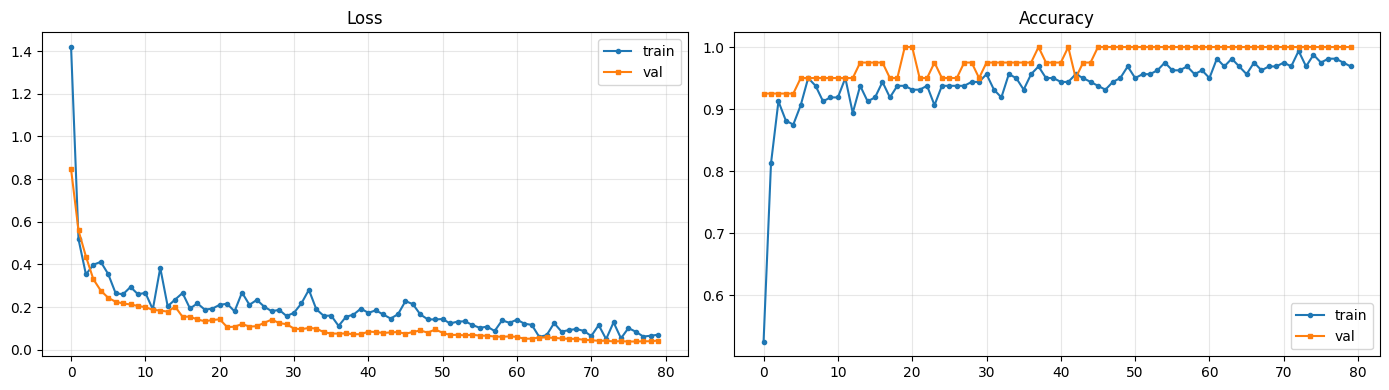

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train', marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='val', marker='s', markersize=3)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['accuracy'], label='train', marker='o', markersize=3)
axes[1].plot(history.history['val_accuracy'], label='val', marker='s', markersize=3)
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Sauvegarde du modèle

In [12]:
# Sauvegarde du classifieur (le MLP)
classifier.save(MODEL_DIR / 'soundwatch_v5_yamnet.keras')

metadata = {
    'approach': 'YAMNet embeddings + MLP classifier (transfer learning)',
    'classes': SELECTED_CATEGORIES,
    'idx_to_category': {str(k): v for k, v in idx_to_category.items()},
    'n_classes': n_classes,
    'yamnet_url': 'https://tfhub.dev/google/yamnet/1',
    'embedding_dim': 1024,
    'sample_rate_yamnet': 16000,
    'best_val_accuracy': float(best_val),
    'notes': 'SoundWatch v5 : YAMNet embeddings + MLP, transfer learning',
}

with open(MODEL_DIR / 'soundwatch_v5_yamnet_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'✅ Modèle v5 sauvegardé : {MODEL_DIR / "soundwatch_v5_yamnet.keras"}')
print(f'📊 Val accuracy : {best_val:.2%}')
print(f'\nClasses : {SELECTED_CATEGORIES}')

✅ Modèle v5 sauvegardé : models/soundwatch_v5_yamnet.keras
📊 Val accuracy : 100.00%

Classes : ['siren', 'clock_alarm', 'crying_baby', 'door_wood_knock', 'clapping']


## 12. Matrice de confusion + rapport

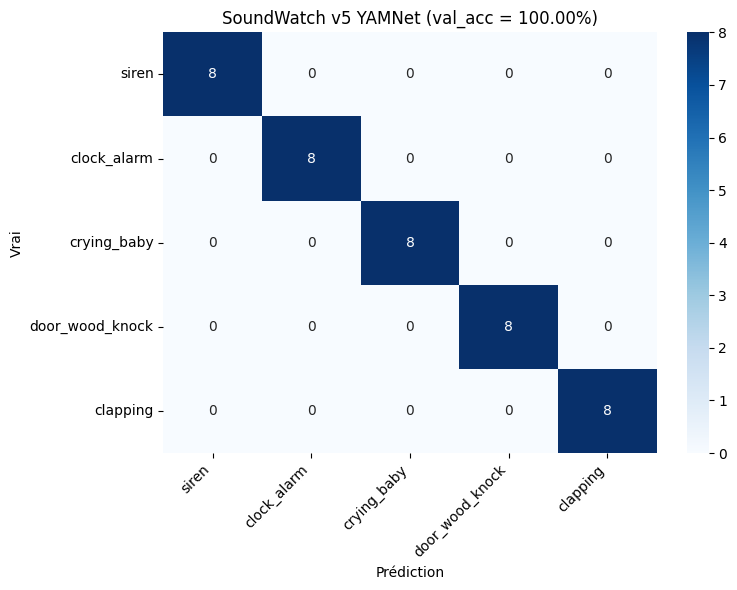

                 precision    recall  f1-score   support

          siren       1.00      1.00      1.00         8
    clock_alarm       1.00      1.00      1.00         8
    crying_baby       1.00      1.00      1.00         8
door_wood_knock       1.00      1.00      1.00         8
       clapping       1.00      1.00      1.00         8

       accuracy                           1.00        40
      macro avg       1.00      1.00      1.00        40
   weighted avg       1.00      1.00      1.00        40



In [13]:
y_pred = classifier.predict(X_val, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_val, y_pred, labels=list(range(n_classes)))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SELECTED_CATEGORIES,
            yticklabels=SELECTED_CATEGORIES)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel('Prédiction')
plt.ylabel('Vrai')
plt.title(f'SoundWatch v5 YAMNet (val_acc = {best_val:.2%})')
plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred, target_names=SELECTED_CATEGORIES, zero_division=0))

## ✅ Terminé

Modèle prêt dans `models/soundwatch_v5_yamnet.keras`.

**Pour utiliser ce modèle en live**, il faudra un script qui :
1. Charge YAMNet (depuis tensorflow-hub)
2. Charge le classifieur MLP (`soundwatch_v5_yamnet.keras`)
3. Pour chaque buffer audio du micro :
   - Resample à 16000 Hz
   - Passe dans YAMNet → embedding 1024d
   - Passe l'embedding dans le MLP → prédiction

Je te livre ce script (+ l'app Streamlit) après confirmation de l'accuracy.

In [14]:
# Charger les noms des 521 classes YAMNet
import csv
import urllib.request

class_map_path = yamnet_model.class_map_path().numpy().decode('utf-8')
with open(class_map_path) as f:
    yamnet_classes = [row['display_name'] for row in csv.DictReader(f)]

print(f'Total classes YAMNet : {len(yamnet_classes)}')

# Chercher les index des classes "parole/silence"
keywords = ['speech', 'conversation', 'silence', 'narration', 'background', 'noise', 'inside']
for keyword in keywords:
    matches = [(i, c) for i, c in enumerate(yamnet_classes) if keyword.lower() in c.lower()]
    print(f'\n"{keyword}" :')
    for i, c in matches[:5]:
        print(f'  {i:4d} : {c}')

Total classes YAMNet : 521

"speech" :
     0 : Speech
     1 : Child speech, kid speaking
     5 : Speech synthesizer
    65 : Hubbub, speech noise, speech babble

"conversation" :
     2 : Conversation

"silence" :
   494 : Silence

"narration" :
     3 : Narration, monologue

"background" :
   262 : Background music

"noise" :
    65 : Hubbub, speech noise, speech babble
   279 : Wind noise (microphone)
   321 : Traffic noise, roadway noise
   507 : Noise
   508 : Environmental noise

"inside" :
   500 : Inside, small room
   501 : Inside, large room or hall
   502 : Inside, public space
